In [1]:
import pandas as pd

#datasets
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")

In [2]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Translation": translation,
    "Geolocation": geolocation
}

summary = pd.DataFrame(columns=["Dataset", "Rows", "Columns", "Missing Values", "Duplicates"])

for name, df in datasets.items():
    summary.loc[len(summary)] = [
        name,
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]

summary

,Dataset,Rows,Columns,Missing Values,Duplicates
0,Customers,99441,5,0,0
1,Orders,99441,8,4908,0
2,Order Items,112650,7,0,0
3,Payments,103886,5,0,0
4,Reviews,99224,7,145903,0
5,Products,32951,9,2448,0
6,Sellers,3095,4,0,0
7,Translation,71,2,0,0
8,Geolocation,1000163,5,0,261831


In [3]:
summary.to_csv("../reports/data_quality_summary.csv", index=False)

In [4]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Remove duplicate geolocation rows
geolocation = geolocation.drop_duplicates()

# Fill missing product category
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

print("Cleaning completed!")

Cleaning completed!


In [5]:
customers.to_csv("../data/processed/customers_clean.csv", index=False)
orders.to_csv("../data/processed/orders_clean.csv", index=False)
order_items.to_csv("../data/processed/order_items_clean.csv", index=False)
payments.to_csv("../data/processed/payments_clean.csv", index=False)
reviews.to_csv("../data/processed/reviews_clean.csv", index=False)
products.to_csv("../data/processed/products_clean.csv", index=False)
sellers.to_csv("../data/processed/sellers_clean.csv", index=False)
translation.to_csv("../data/processed/category_translation_clean.csv", index=False)
geolocation.to_csv("../data/processed/geolocation_clean.csv", index=False)

print("All cleaned datasets saved successfully!")

All cleaned datasets saved successfully!


# EDA

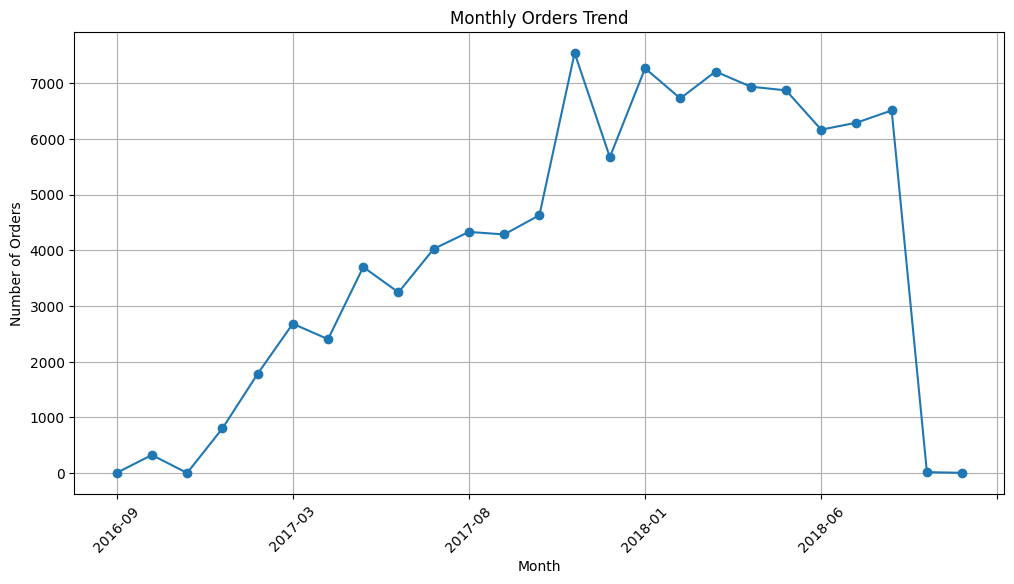

In [6]:
import matplotlib.pyplot as plt
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

monthly_orders = (
    orders.groupby(orders["order_purchase_timestamp"].dt.to_period("M"))
    .size()
)

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(12,6))
monthly_orders.plot(marker="o")
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)

plt.savefig("../images/monthly_orders_trend.png", dpi=300, bbox_inches="tight")
plt.show()

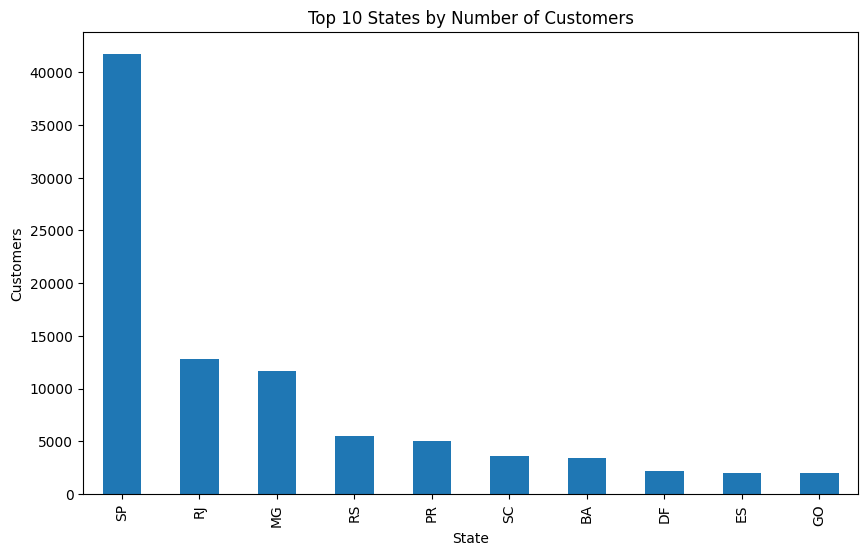

In [7]:
top_states = customers["customer_state"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind="bar")

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Customers")

plt.savefig("../images/top_states.png", dpi=300, bbox_inches="tight")
plt.show()

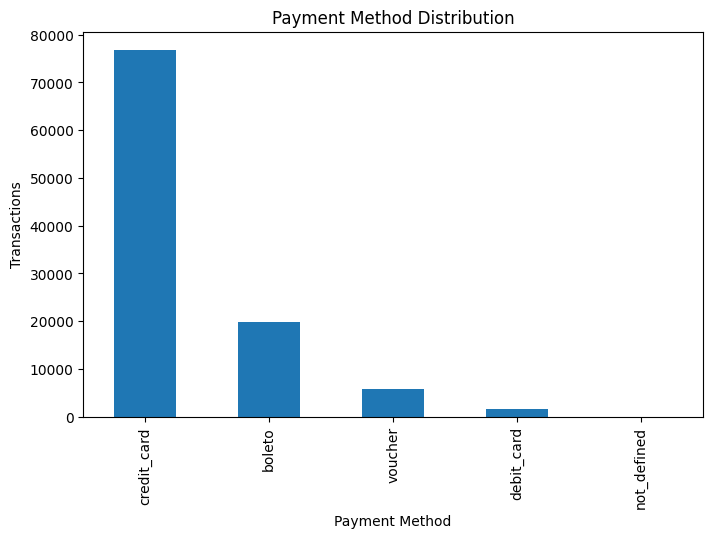

In [8]:
payment_counts = payments["payment_type"].value_counts()

plt.figure(figsize=(8,5))
payment_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Transactions")

plt.savefig("../images/payment_methods.png", dpi=300, bbox_inches="tight")
plt.show()

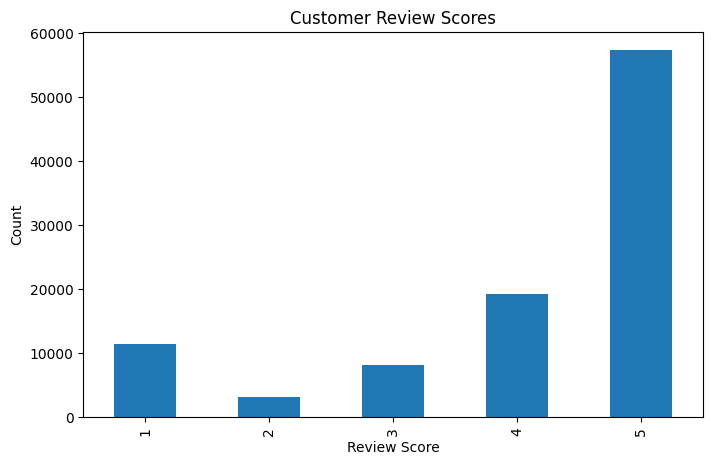

In [9]:
review_scores = reviews["review_score"].value_counts().sort_index()

plt.figure(figsize=(8,5))
review_scores.plot(kind="bar")

plt.title("Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")

plt.savefig("../images/review_scores.png", dpi=300, bbox_inches="tight")
plt.show()

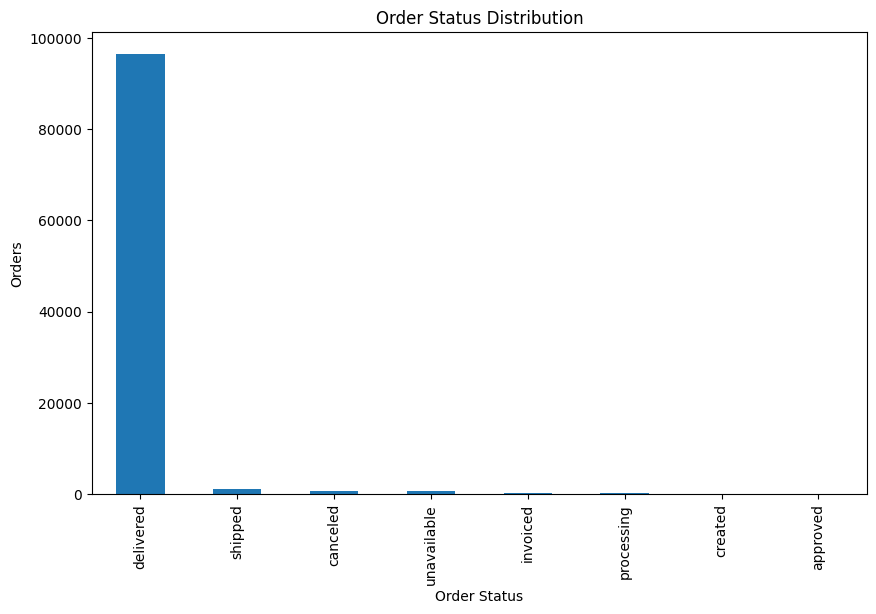

In [10]:
order_status = orders["order_status"].value_counts()

plt.figure(figsize=(10,6))
order_status.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")

plt.savefig("../images/order_status.png", dpi=300, bbox_inches="tight")
plt.show()

# Revenue analysis

In [11]:
# Merge order items with orders
sales = order_items.merge(
    orders[["order_id", "customer_id", "order_purchase_timestamp", "order_status"]],
    on="order_id"
)

# Merge with customers
sales = sales.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id"
)

sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered,SP


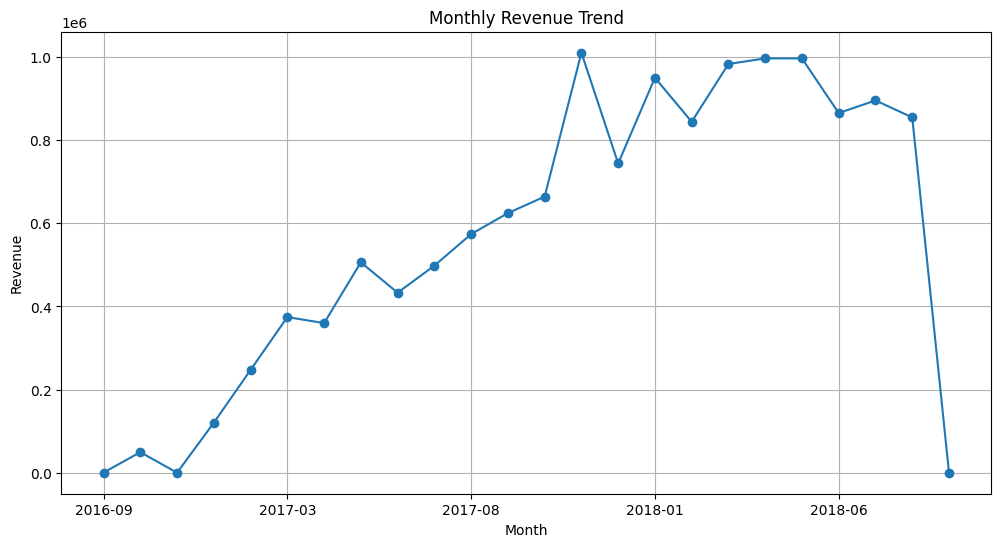

In [12]:
#Monthly revenue
sales["month"] = sales["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_revenue = (
    sales.groupby("month")["price"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12,6))
monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.savefig("../images/monthly_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

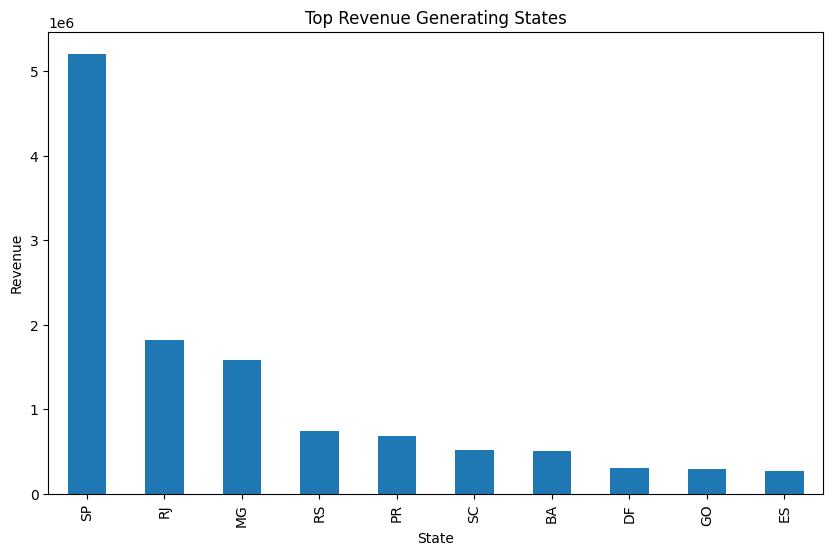

In [13]:
#Top 10 revenue states
state_revenue = (
    sales.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
state_revenue.plot(kind="bar")

plt.title("Top Revenue Generating States")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.savefig("../images/state_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

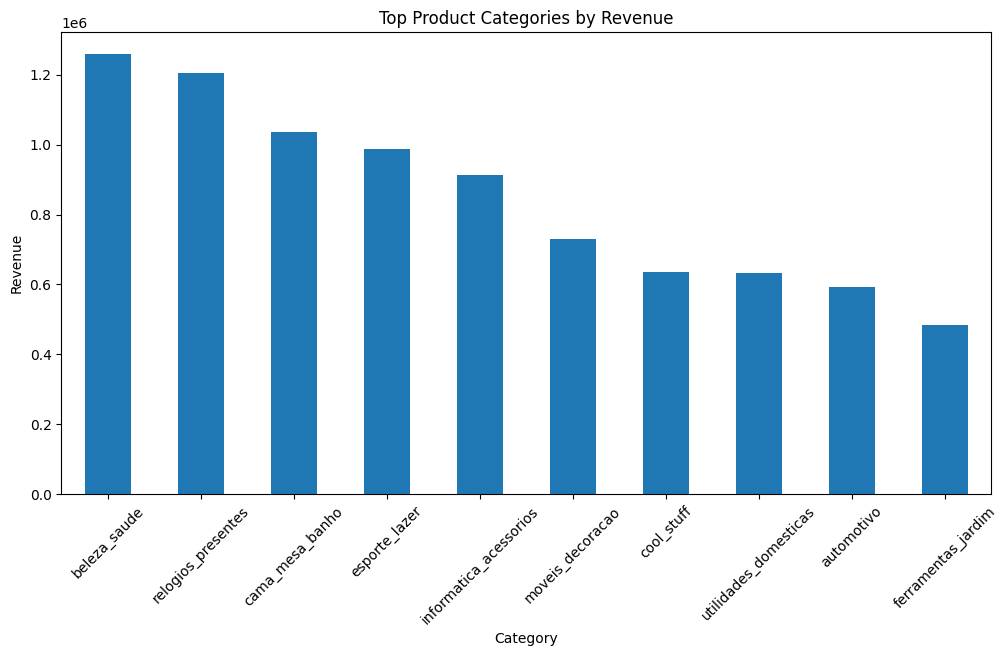

In [14]:
#top 10 products by revenue
sales = sales.merge(
    products[["product_id","product_category_name"]],
    on="product_id"
)

top_categories = (
    sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_categories.plot(kind="bar")

plt.title("Top Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.savefig("../images/top_categories.png", dpi=300, bbox_inches="tight")

plt.show()

# Key Business Insights

In [15]:
print("Total Customers:", customers["customer_unique_id"].nunique())

print("Total Orders:", orders["order_id"].nunique())

print("Total Products:", products["product_id"].nunique())

print("Total Sellers:", sellers["seller_id"].nunique())

print("Total Revenue: ₹", round(order_items["price"].sum(),2))

Total Customers: 96096
Total Orders: 99441
Total Products: 32951
Total Sellers: 3095
Total Revenue: ₹ 13591643.7


#Business Insights

In [16]:
kpis = {
    "Total Customers": customers["customer_unique_id"].nunique(),
    "Total Orders": orders["order_id"].nunique(),
    "Total Products": products["product_id"].nunique(),
    "Total Sellers": sellers["seller_id"].nunique(),
    "Total Revenue": round(order_items["price"].sum(),2)
}

kpis

{'Total Customers': 96096,
 'Total Orders': 99441,
 'Total Products': 32951,
 'Total Sellers': 3095,
 'Total Revenue': np.float64(13591643.7)}